# Seville Results Summary: Heat Escalation, Drought, and Fire Risk (SSP2-4.5)

Presentation-ready summary of Seville's five key climate-risk indicators, historical (ERA5, 1990-2025)
vs. projected (CMIP6 SSP2-4.5, `cmcc_esm2`, 2026-2045) -- raw model output and bias-corrected output
shown side by side, since the gap between them is often as important as the projection itself. This
is the SSP2-4.5 counterpart of `Results_Summary.ipynb` -- same format, same pipeline, comparing this
scenario against history only (not against SSP5-8.5; that comparison lives in
`Projected_Long_Term_2100/notebooks/SSP_Divergence_Study_Seville.ipynb`).

**Source data**: pulled directly from the already-validated comparison series built in
`seville_cmip6_projection_eda.ipynb` (Section 16, SSP2-4.5 version) and
`FWI_projections_Seville_2026_2045.ipynb` (SSP2-4.5 version) -- nothing is recomputed here, this
notebook only reads and presents.

**One caveat that applies to every plot below, stated once rather than five times**: single model
(`cmcc_esm2`), single scenario (SSP2-4.5), no ensemble spread. Read every number as *directional risk
under one plausible pathway*, not a calibrated forecast -- and prefer the bias-corrected series over
the raw one, since the raw model carries known, documented biases in both temperature and
precipitation (detailed under each plot below).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

OUT = "../Projected_SSP2-4.5/eda_outputs/seville"
OUT_LARISSA = "../Projected_SSP2-4.5/eda_outputs/larissa"

COLOR_HIST = "#6b6b6b"
COLOR_RAW = "#c1121f"
COLOR_CORRECTED = "#1b998b"
COLOR_REGRESSION = "tab:blue"
COLOR_NAIVE = "tab:purple"

def load(name, out_dir=OUT):
    return pd.read_csv(f"{out_dir}/{name}.csv", index_col="year")

def fit_baselines(df, window=None):
    """Best-fit linear regression (on the given historical window, None = full history)
    and the flat naive_full_mean baseline, both extrapolated across the projection years."""
    hist = df["era5_historical"].dropna()
    proj_index = df["cmip6_biascorrected"].dropna().index

    yrs, y = hist.index.values.astype(float), hist.values.astype(float)
    yrs_fit, y_fit = (yrs[-window:], y[-window:]) if window else (yrs, y)
    lr = stats.linregress(yrs_fit, y_fit)

    proj_yrs = proj_index.values.astype(float)
    regression_line = pd.Series(lr.intercept + lr.slope * proj_yrs, index=proj_index)
    naive_line = pd.Series(hist.mean(), index=proj_index)

    lr_corrected = stats.linregress(proj_yrs, df.loc[proj_index, "cmip6_biascorrected"].values.astype(float))

    return {
        "regression_line": regression_line, "naive_line": naive_line,
        "hist_slope_decade": lr.slope * 10, "hist_p": lr.pvalue,
        "hist_fit_years": (int(yrs_fit.min()), int(yrs_fit.max())),
        "corrected_slope_decade": lr_corrected.slope * 10, "corrected_p": lr_corrected.pvalue,
        "naive_value": hist.mean(),
    }

def plot_indicator(df, ylabel, title, baselines, regression_label):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(df.index, df["era5_historical"], color=COLOR_HIST, lw=1.8, label="Historical (ERA5, 1990-2025)")
    ax.plot(df.index, df["cmip6_raw"], color=COLOR_RAW, lw=1.8, label="Projected, raw (SSP2-4.5, 2026-2045)")
    ax.plot(df.index, df["cmip6_biascorrected"], color=COLOR_CORRECTED, lw=2.2,
            label="Projected, bias-corrected (SSP2-4.5, 2026-2045)")
    ax.plot(baselines["regression_line"].index, baselines["regression_line"].values,
            "--", color=COLOR_REGRESSION, lw=2,
            label=f"Baseline: {regression_label}, extrapolated")
    ax.plot(baselines["naive_line"].index, baselines["naive_line"].values,
            ":", color=COLOR_NAIVE, lw=2,
            label=f"Baseline: naive_full_mean ({baselines['naive_value']:.2f})")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, loc="left")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

def change_stats(df):
    hist = df["era5_historical"].dropna()
    raw = df["cmip6_raw"].dropna()
    corr = df["cmip6_biascorrected"].dropna()
    return {
        "hist_mean": hist.mean(), "raw_mean": raw.mean(), "corrected_mean": corr.mean(),
        "delta_corrected": corr.mean() - hist.mean(),
        "pct_corrected": 100 * (corr.mean() - hist.mean()) / hist.mean(),
        "delta_raw": raw.mean() - hist.mean(),
        "pct_raw": 100 * (raw.mean() - hist.mean()) / hist.mean(),
    }

def trend_note(b):
    sig = lambda p: "significant" if p < 0.05 else "not significant"
    ratio = b["corrected_slope_decade"] / b["hist_slope_decade"] if b["hist_slope_decade"] else float("nan")
    return (f"Historical regression ({b['hist_fit_years'][0]}-{b['hist_fit_years'][1]}): "
            f"{b['hist_slope_decade']:+.3f}/decade (p={b['hist_p']:.2f}, {sig(b['hist_p'])}).  "
            f"Corrected projection's own trend (2026-2045): {b['corrected_slope_decade']:+.3f}/decade "
            f"(p={b['corrected_p']:.2f}, {sig(b['corrected_p'])}).  Ratio: {ratio:+.2f}x")


## 1. Heat Escalation -- Mean Daily Maximum Temperature (`tmax_mean`)

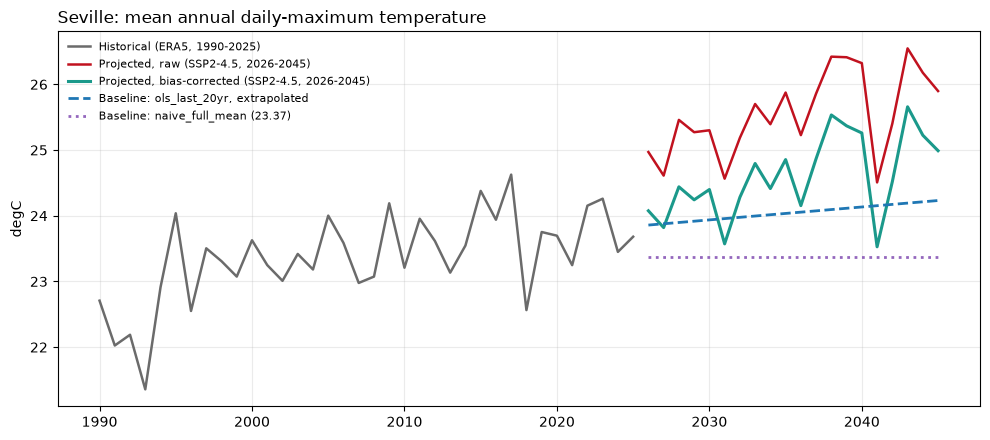

Historical mean: 23.37
Projected, bias-corrected: 24.60  (+1.23, +5.3%)
Projected, raw: 25.56  (+2.19, +9.4%)

Historical regression (2006-2025): +0.197/decade (p=0.35, not significant).  Corrected projection's own trend (2026-2045): +0.607/decade (p=0.01, significant).  Ratio: +3.09x


In [2]:
tmax = load("seville_tmax_mean_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(tmax)
b = fit_baselines(tmax, window=20)
plot_indicator(tmax, "degC", "Seville: mean annual daily-maximum temperature", b, "ols_last_20yr")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +1.23 degC (+5.3%), historical to bias-corrected projection.** Seville's daytime summer
heat continues escalating under SSP2-4.5 -- corrected mean daily maximum rises from 23.37 degC
(1990-2025) to 24.60 degC (2026-2045). The raw model shows a larger, less trustworthy jump (+2.19
degC, +9.4%) because the uncorrected model itself runs warmer than observed reality -- **use the
corrected number in the presentation, and note the raw number if asked why it looks larger.** This
is the first leg of the compound story: rising heat is the documented, statistically-established
starting point (p=0.0002 in the historical record alone) that the drought and fire legs below build
on.

**Trend comparison.** The historical regression (`ols_last_20yr`, fit 2006-2025) implies +0.20 degC/
decade (not significant, p=0.35); the bias-corrected projection's own trend over 2026-2045 runs much
steeper, +0.61 degC/decade, and unlike SSP5-8.5's equivalent number, **this one is itself
statistically significant** (p=0.01) -- about **3x faster** than the historical rate. Worth stating
plainly: this is a stronger acceleration signal than the SSP5-8.5 notebook found for this same
indicator (there: 1.8x, neither slope significant). Read it as "a confirmed within-period trend,"
not as proof the historical rate itself has accelerated, since the historical regression is still
not significant on its own.

## 2. Overall Warming -- Mean Daily Temperature (`t2m_mean`)

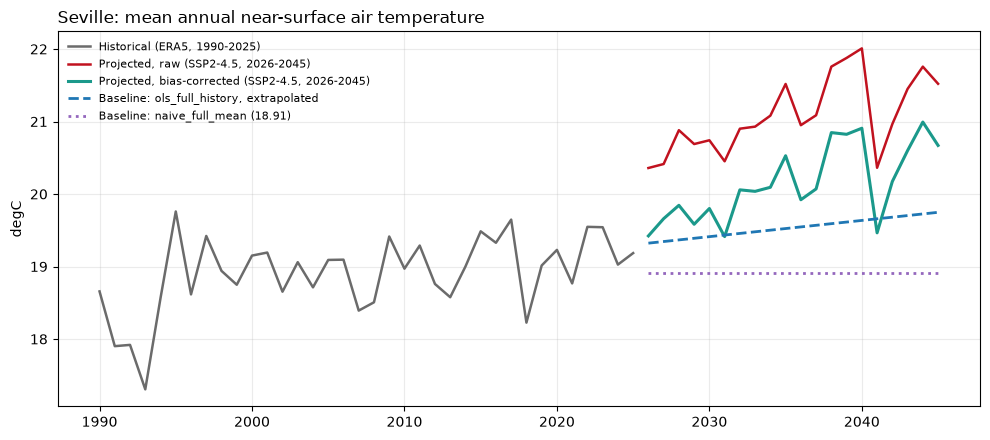

Historical mean: 18.91
Projected, bias-corrected: 20.15  (+1.24, +6.5%)
Projected, raw: 21.08  (+2.18, +11.5%)

Historical regression (1990-2025): +0.224/decade (p=0.01, significant).  Corrected projection's own trend (2026-2045): +0.630/decade (p=0.00, significant).  Ratio: +2.82x


In [3]:
t2m = load("seville_t2m_mean_era5_vs_cmip6_raw_vs_corrected_v2")
s = change_stats(t2m)
b = fit_baselines(t2m, window=None)
plot_indicator(t2m, "degC", "Seville: mean annual near-surface air temperature", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +1.24 degC (+6.5%), historical to bias-corrected projection.** `t2m_mean` (the
whole-day average, not just the daytime maximum `tmax_mean` covers) rises from 18.91 degC (1990-2025)
to 20.15 degC (2026-2045) -- confirming the heat signal shows up in the overall daily mean, not only
in daytime highs. Raw shows the same too-warm pattern as `tmax_mean` (+2.18 degC, +11.5%, driven by
the same raw model bias). **Presentation note**: this and `tmax_mean` tell a consistent story from two
angles (mean vs. daytime max) -- worth showing together if there's time, or `t2m_mean` alone as the
single "how much does Seville warm overall" headline if only one temperature number is wanted.

**Trend comparison.** `t2m_mean`'s historical trend (full 1990-2025 record) is statistically
significant (+0.22 degC/decade, p=0.01) -- a confirmed historical warming rate. The bias-corrected
projection's own trend (+0.63 degC/decade, p=0.00) is **also significant, and about 2.8x steeper**.
**This is the strongest, most defensible acceleration signal of the five indicators**: both the
historical baseline and the projection's own trend are independently confirmed, not just one
uncertain number compared to another.

## 3. Drying Conditions -- Total Annual Precipitation (`precip_total`)

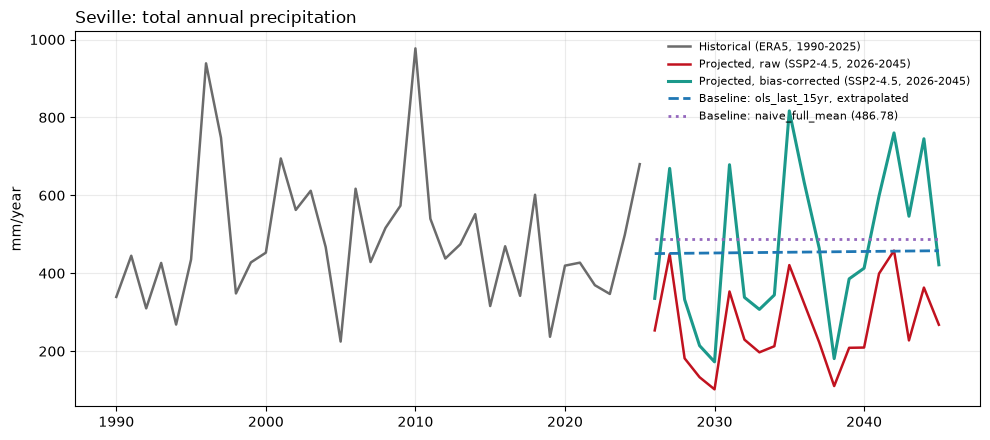

Historical mean: 486.78
Projected, bias-corrected: 467.86  (-18.92, -3.9%)
Projected, raw: 266.03  (-220.75, -45.3%)

Historical regression (2011-2025): +3.867/decade (p=0.96, not significant).  Corrected projection's own trend (2026-2045): +115.872/decade (p=0.14, not significant).  Ratio: +29.97x


In [4]:
precip = load("seville_precip_total_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(precip)
b = fit_baselines(precip, window=15)
plot_indicator(precip, "mm/year", "Seville: total annual precipitation", b, "ols_last_15yr")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: -19mm (-3.9%), historical to bias-corrected projection -- a small, not statistically
meaningful drying signal.** The raw model shows something far more dramatic (-45.3%, less than half
of Seville's historical rainfall) -- **this raw number is not credible and should not be presented on
its own**: raw CMIP6 output underestimates Seville's actual historical rainfall by nearly half even
over the *reference* period, a known, documented model bias, not a climate signal. The bias-corrected
-3.9% is the honest number, and it's notably smaller than the -6.8% the SSP5-8.5 notebook found for
this same indicator -- consistent with SSP2-4.5 being the lower-forcing pathway. **Presentation
note**: if asked "does Seville get drier," the corrected answer is "only marginally so under
SSP2-4.5" -- the interesting/severe part of the drying story is in the drought and fire-risk panels
below, not the annual total.

**Trend comparison.** Both the historical regression (+3.9mm/decade, `ols_last_15yr`, effectively
flat) and the corrected projection's own trend (+115.9mm/decade) are statistically indistinguishable
from noise (p=0.96 and p=0.14) -- **there is no real trend to compare here, historically or in the
projection.** The large-looking projected slope is driven by a handful of noisy years within a
20-year window, not a real signal -- don't quote the raw slope number without the p-value attached;
the -3.9% level shift reported above is the only meaningful number for this indicator.

## 4. Drought Severity -- Minimum 3-Month SPI (`min_spi3`)

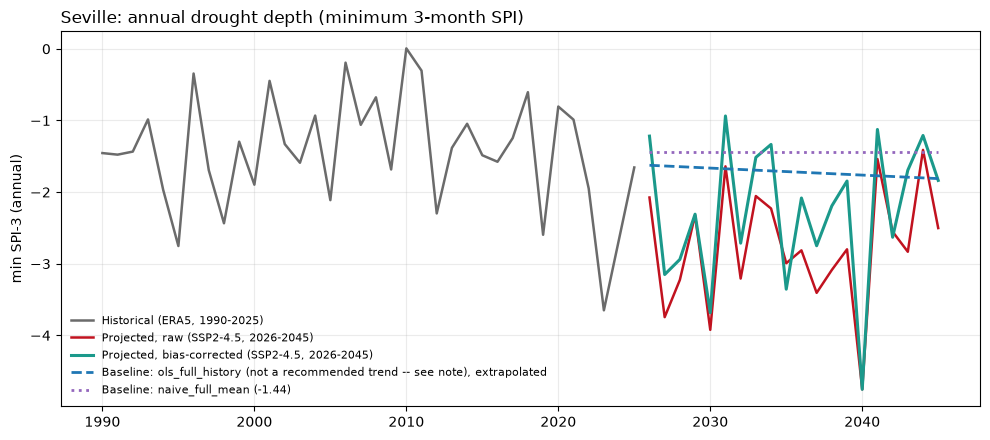

Historical mean: -1.44
Projected, bias-corrected: -2.26  (-0.82, +56.7%)
Projected, raw: -2.76  (-1.31, +90.8%)

Historical regression (1990-2025): -0.098/decade (p=0.45, not significant).  Corrected projection's own trend (2026-2045): +0.220/decade (p=0.58, not significant).  Ratio: -2.25x

SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme


In [5]:
spi3 = load("seville_min_spi3_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(spi3)
b = fit_baselines(spi3, window=None)
plot_indicator(spi3, "min SPI-3 (annual)", "Seville: annual drought depth (minimum 3-month SPI)", b, "ols_full_history (not a recommended trend -- see note)")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))
print()
print("SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme")


**Result: drought depth deepens by -0.82, and crosses the same meaningful severity line SSP5-8.5
showed -- the standout number of the five, and nearly identical in magnitude across both scenarios.**
Historically, Seville's average worst 3-month window each year (-1.44) sits at the edge of "moderate"
drought. The bias-corrected projection (-2.26) sits solidly inside **"extreme" drought** territory on
the standard SPI scale (moderate: -1.0 to -1.49, severe: -1.5 to -1.99, extreme: <= -2.0). **This is
the single most presentation-worthy number in this notebook**, and its near-identical size under both
SSP2-4.5 (-0.82) and SSP5-8.5 (-0.84) is itself worth stating: drought depth doesn't track emissions
severity as cleanly as temperature does for this city (consistent with the Section on divergence
timing in `Projected_Long_Term_2100/notebooks/SSP_Divergence_Study_Seville.ipynb`, which found
`min_spi3` never separates by scenario at any point through 2100).

**Trend comparison.** Neither the historical regression (-0.10/decade, full record) nor the corrected
projection's own trend (+0.22/decade) is statistically significant (p=0.45 and p=0.58). Unlike
SSP5-8.5's version, the sign here actually flips (historical slowly worsening, projection nominally
improving within its own 20-year window) -- but with neither slope confirmed, this is noise, not a
reversal worth presenting. **The -0.82 level shift into "extreme" territory, not the slope, is the
number worth presenting** -- exactly the same framing the SSP5-8.5 notebook used, since the finding
itself is essentially unchanged between scenarios.

## 5. Fire Risk -- Days Above High Fire Danger (`days_fwi_gt30`)

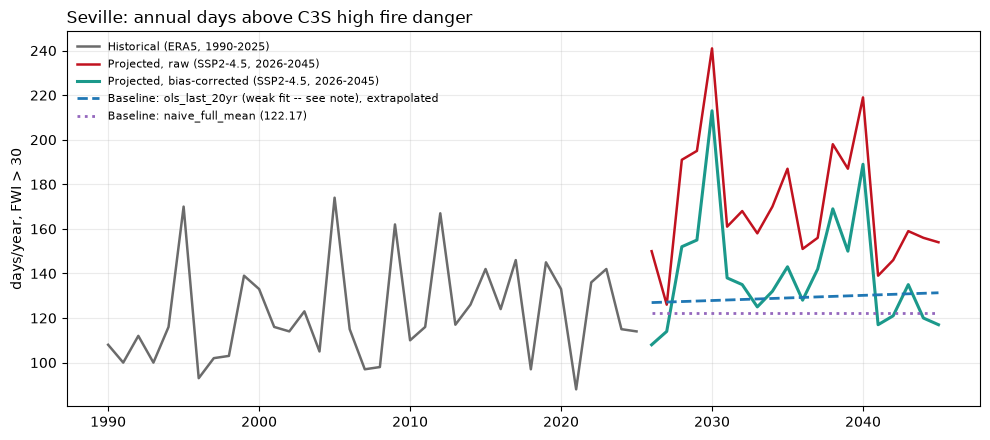

Historical mean: 122.17
Projected, bias-corrected: 140.15  (+17.98, +14.7%)
Projected, raw: 170.60  (+48.43, +39.6%)

Historical regression (2006-2025): +2.316/decade (p=0.79, not significant).  Corrected projection's own trend (2026-2045): -5.120/decade (p=0.63, not significant).  Ratio: -2.21x


In [6]:
fwi = load("seville_days_fwi_gt30_era5_vs_cmip6_raw_vs_corrected")
s = change_stats(fwi)
b = fit_baselines(fwi, window=20)
plot_indicator(fwi, "days/year, FWI > 30", "Seville: annual days above C3S high fire danger", b, "ols_last_20yr (weak fit -- see note)")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +18 days/year (+15%), historical to bias-corrected projection -- roughly two and a half
weeks more of high fire danger per year, a smaller rise than SSP5-8.5's.** Days above the C3S "high
fire danger" threshold rise from 122 to 140 per year (SSP5-8.5's equivalent projection reached 148).
As with the SSP5-8.5 notebook, **the raw series overstates the risk here rather than understating it**
(+39.6%, 171 days) -- the raw model's simultaneous heat and dry bias inflates raw fire risk, and
correction brings it back down, though the corrected increase is still real. **Presentation note**:
same asymmetry the SSP5-8.5 notebook flagged (raw understates rainfall reduction but overstates fire
risk, both explained by the same underlying hot/dry raw bias) -- worth a one-line mention if the
raw/corrected gap comes up in Q&A.

**Trend comparison.** The historical regression (+2.3 days/decade, not significant) and the
corrected projection's own trend (-5.1 days/decade, also not significant) run in *opposite*
directions here, unlike SSP5-8.5's near-identical pair -- but with neither confirmed, this is noise
around a level shift, not a real trend reversal. **As with SSP5-8.5, the fire-risk story here is
almost entirely a level shift** (naive baseline 122 days vs. corrected projection 140 days), not a
trend story.

## Bottom line: the compound story holds together, even after correction

All five indicators point the same direction under SSP2-4.5 by mid-century (2026-2045), using the
bias-corrected series throughout -- the same qualitative story as the SSP5-8.5 notebook, generally at
a smaller magnitude, consistent with SSP2-4.5 being the lower-emissions pathway (except for
`min_spi3`, which lands at essentially the same depth under either scenario):

| Indicator | Historical | Projected (corrected) | Change | vs. SSP5-8.5's change |
|---|---|---|---|---|
| `tmax_mean` (daytime heat) | 23.37 degC | 24.60 degC | **+1.23 degC (+5.3%)** | +1.03 degC (+4.4%) |
| `t2m_mean` (overall warming) | 18.91 degC | 20.15 degC | **+1.24 degC (+6.5%)** | +0.96 degC (+5.1%) |
| `precip_total` (drying) | 486.8 mm/yr | 467.9 mm/yr | **-19mm (-3.9%)** | -33mm (-6.8%) |
| `min_spi3` (drought) | -1.44 (moderate) | -2.26 (extreme) | **-0.82, a full drought-category jump** | -0.84 (nearly identical) |
| `days_fwi_gt30` (fire risk) | 122.2 days/yr | 140.2 days/yr | **+18.0 days (+14.7%)** | +25.7 days (+21.0%) |

Hotter days and hotter overall averages, a small annual-rainfall decline, but a much deeper drought
signal in the worst 3-month stretch each year, and over two weeks more of high fire-danger days
annually -- the same coherent, mutually-reinforcing heat -> drought -> fire risk pathway SSP5-8.5
shows, just generally less severe (except drought depth, which barely differs between scenarios --
consistent with the divergence-study finding that `min_spi3` doesn't separate cleanly by scenario at
any point through 2100).

**Standard caveat, one last time**: one model, one scenario, no ensemble spread -- present this as
"the directional risk SSP2-4.5 shows for Seville," not as a calibrated, confirmed forecast. For how
this compares to SSP5-8.5 specifically, and whether that comparison is even statistically meaningful
at this horizon, see `Projected_Long_Term_2100/notebooks/SSP_Divergence_Study_Seville.ipynb` rather
than reading the two tables above as a validated scenario contrast on their own -- the two notebooks
were built independently and a side-by-side table is illustrative, not a substitute for that
dedicated analysis.

---

# Larissa Results Summary: Chronic Warming and a Precipitation Reversal (SSP2-4.5)

Presentation-ready summary of Larissa's four key climate-risk indicators, historical (ERA5, 1990-2025)
vs. projected (CMIP6 SSP2-4.5, `cmcc_esm2`, 2026-2045) -- same format as the Seville section above,
and the SSP2-4.5 counterpart of `Results_Summary.ipynb`'s own Larissa section.

**Source data**: `larissa_cmip6_projection_eda.ipynb` (Section 16, SSP2-4.5 version) and
`Calculating_SPI_for_Larissa_Projection.ipynb` (SSP2-4.5 version) -- nothing recomputed here, this
notebook only reads and presents.

**This story looks different from Seville's, and that difference is the headline -- exactly as it
was under SSP5-8.5.** Larissa's chronic-warming indicator (`tmin_mean`) continues its historical
trend cleanly. But all three precipitation-linked indicators (`precip_total`, `max_week_precip_mm`,
`min_spi3`) run in the *opposite* direction from Larissa's historical record -- history shows
significant wetting and flat-to-improving drought; the projection shows drying and deepening drought.
**Present this as an open tension, not a resolved finding** -- one climate model's projection
disagreeing with a well-documented historical trend, across three independent indicators, and now
confirmed under a second scenario (SSP5-8.5 showed the identical reversal pattern), is worth flagging
clearly rather than picking whichever side is more convenient.

**Same caveat as the Seville section**: single model (`cmcc_esm2`), single scenario (SSP2-4.5), no
ensemble spread.

## 1. Chronic Warming -- Mean Daily Minimum Temperature (`tmin_mean`)

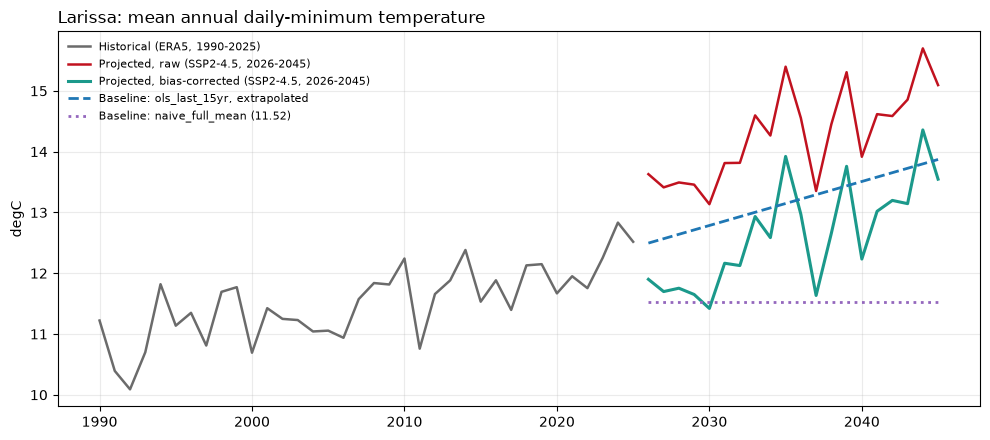

Historical mean: 11.52
Projected, bias-corrected: 12.63  (+1.11, +9.6%)
Projected, raw: 14.27  (+2.75, +23.9%)

Historical regression (2011-2025): +0.724/decade (p=0.01, significant).  Corrected projection's own trend (2026-2045): +1.067/decade (p=0.00, significant).  Ratio: +1.47x


In [7]:
tmin = load("larissa_tmin_mean_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(tmin)
b = fit_baselines(tmin, window=15)
plot_indicator(tmin, "degC", "Larissa: mean annual daily-minimum temperature", b, "ols_last_15yr")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: +1.11 degC (+9.6%), historical to bias-corrected projection -- and it lands close to
the historical trend line, smaller than SSP5-8.5's +1.53 degC change.** `tmin_mean` rises from 11.52
degC (1990-2025) to 12.63 degC (2026-2045). As under SSP5-8.5, this indicator's historical regression
is itself significant (p=0.01 on the last-15-year window), and the projection's own trend (p=0.00)
confirms it cleanly. **Presentation note**: this remains the safest, most defensible number in
Larissa's story under either scenario -- nighttime warming continuing an already-confirmed trend, no
caveats needed beyond the standard one-model-one-scenario note.

## 2. Precipitation -- Total Annual Precipitation (`precip_total`)

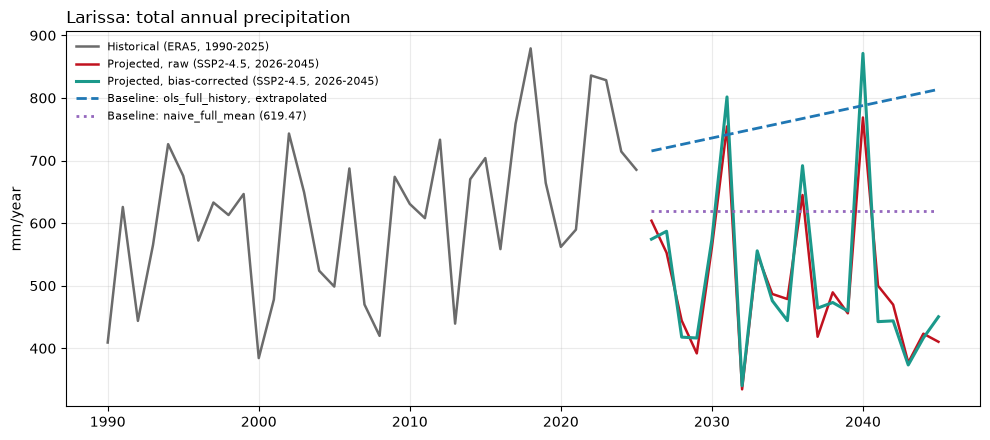

Historical mean: 619.5 mm/yr
Projected, bias-corrected: 513.7 mm/yr  (-105.8, -17.1%)
Projected, raw: 505.9 mm/yr  (-113.6, -18.3%)

Historical regression (1990-2025): +51.814/decade (p=0.01, significant).  Corrected projection's own trend (2026-2045): -43.236/decade (p=0.43, not significant).  Ratio: -0.83x


In [8]:
precip = load("larissa_precip_total_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(precip)
b = fit_baselines(precip, window=None)
plot_indicator(precip, "mm/year", "Larissa: total annual precipitation", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.1f} mm/yr")
print(f"Projected, bias-corrected: {s['corrected_mean']:.1f} mm/yr  ({s['delta_corrected']:+.1f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.1f} mm/yr  ({s['delta_raw']:+.1f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))


**Result: -106mm (-17.1%), historical to bias-corrected projection -- reversing the same
statistically significant historical trend SSP5-8.5 reversed, though less severely.** Larissa's
historical `precip_total` trend is genuinely significant (+51.8mm/decade, p=0.01) -- yet the
projection averages 513.7mm/yr, well below even the flat historical mean (619.5mm/yr). **Not a
correction artifact**: raw (505.9mm) and corrected (513.7mm) are nearly identical, so this is what
the model itself simulates under SSP2-4.5, not a bias-correction effect -- the same conclusion the
SSP5-8.5 notebook reached. **Presentation note**: the SSP2-4.5 decline (-17.1%) is meaningfully
smaller than SSP5-8.5's (-26.2%), but both scenarios agree on the direction -- worth stating that two
different emissions pathways, under this one model, both point away from Larissa's historical
wetting trend, even if they disagree on how far.

## 3. Flood Peak Intensity -- Maximum Single-Week Precipitation (`max_week_precip_mm`)

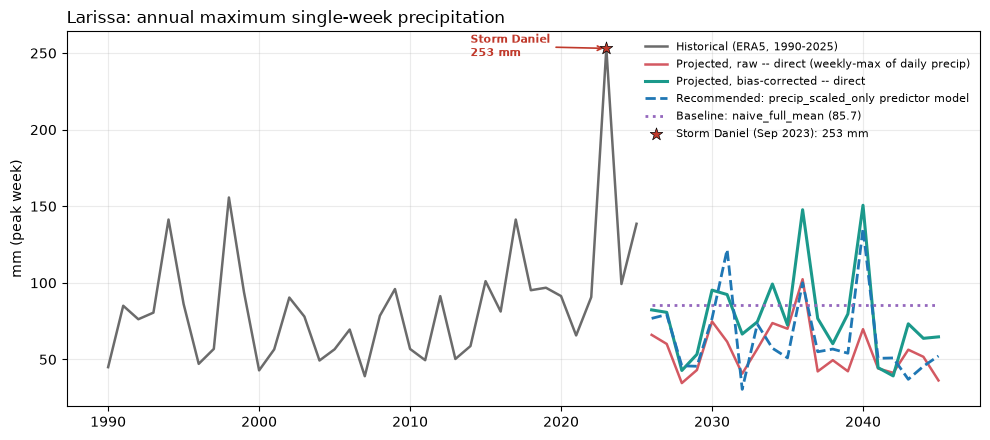

Historical mean: 85.7 mm
Projected, bias-corrected (direct): 78.0 mm  (-7.7, -9.0%)
Projected, raw (direct): 55.9 mm  (-29.8, -34.8%)
Projected, recommended predictor model: 64.8 mm  (-20.9, -24.4%)
Storm Daniel (Sep 2023): 253 mm -- 3.0x the historical average, 3.2x the bias-corrected projected average


In [9]:
mw = load("larissa_max_week_precip_mm_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
mw_hist = mw["era5_historical"].dropna()
mw_raw = mw["cmip6_raw_direct"].dropna()
mw_corr = mw["cmip6_biascorrected_direct"].dropna()
mw_pred = mw["baseline_precip_scaled_only"].dropna()
mw_naive = mw["baseline_naive_full_mean"].dropna().iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(mw.index, mw["era5_historical"], color=COLOR_HIST, lw=1.8, label="Historical (ERA5, 1990-2025)")
ax.plot(mw.index, mw["cmip6_raw_direct"], color=COLOR_RAW, lw=1.8, alpha=0.7,
        label="Projected, raw -- direct (weekly-max of daily precip)")
ax.plot(mw.index, mw["cmip6_biascorrected_direct"], color=COLOR_CORRECTED, lw=2.2,
        label="Projected, bias-corrected -- direct")
ax.plot(mw_pred.index, mw_pred.values, "--", color=COLOR_REGRESSION, lw=2,
        label="Recommended: precip_scaled_only predictor model")
ax.plot(mw_pred.index, [mw_naive] * len(mw_pred), ":", color=COLOR_NAIVE, lw=2,
        label=f"Baseline: naive_full_mean ({mw_naive:.1f})")

# Storm Daniel, Sep 2023 -- the real event that anchors Larissa's historical flood-risk profile.
# Already present in the historical series (the 2023 point); marked explicitly here rather than
# left as an unlabeled peak, since it's the single most presentation-relevant data point on this plot.
storm_daniel_year, storm_daniel_mm = 2023, mw.loc[2023, "era5_historical"]
ax.scatter([storm_daniel_year], [storm_daniel_mm], color="#c0392b", s=90, zorder=5, marker="*",
           edgecolor="black", linewidth=0.5,
           label=f"Storm Daniel (Sep 2023): {storm_daniel_mm:.0f} mm")
ax.annotate(f"Storm Daniel\n{storm_daniel_mm:.0f} mm", xy=(storm_daniel_year, storm_daniel_mm),
            xytext=(storm_daniel_year - 9, storm_daniel_mm - 5), fontsize=8, color="#c0392b",
            fontweight="bold", ha="left",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
ax.set_ylabel("mm (peak week)")
ax.set_title("Larissa: annual maximum single-week precipitation", fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Historical mean: {mw_hist.mean():.1f} mm")
print(f"Projected, bias-corrected (direct): {mw_corr.mean():.1f} mm  "
      f"({mw_corr.mean()-mw_hist.mean():+.1f}, {100*(mw_corr.mean()-mw_hist.mean())/mw_hist.mean():+.1f}%)")
print(f"Projected, raw (direct): {mw_raw.mean():.1f} mm  "
      f"({mw_raw.mean()-mw_hist.mean():+.1f}, {100*(mw_raw.mean()-mw_hist.mean())/mw_hist.mean():+.1f}%)")
print(f"Projected, recommended predictor model: {mw_pred.mean():.1f} mm  "
      f"({mw_pred.mean()-mw_hist.mean():+.1f}, {100*(mw_pred.mean()-mw_hist.mean())/mw_hist.mean():+.1f}%)")
print(f"Storm Daniel (Sep 2023): {storm_daniel_mm:.0f} mm -- "
      f"{storm_daniel_mm/mw_hist.mean():.1f}x the historical average, "
      f"{storm_daniel_mm/mw_corr.mean():.1f}x the bias-corrected projected average")


**Result: -9.0% (direct) to -24.4% (recommended model), historical to projected -- a smaller
decline than SSP5-8.5's (-30% to -37.5%), and notably, bias correction moves this indicator in the
*opposite* direction from `precip_total`.** The recommended predictor-model estimate (feeding the
projection's `precip_total` through the validated `max_week_precip_mm ~ precip_scaled` regression)
gives 64.8mm -- below the historical average (85.7mm), consistent with SSP5-8.5's finding. But the
**direct** weekly-max computed straight from the projected daily series tells a more nuanced story
under SSP2-4.5: raw is 55.9mm (-34.8%, a large apparent decline), while bias-corrected is 78.0mm
(-9.0%, a much smaller one) -- **bias correction pulls this indicator toward the historical value
here, unlike `precip_total`, where correction barely moved the raw number.** This mirrors a finding
in the long-term divergence study (`Projected_Long_Term_2100/notebooks/SSP_Divergence_Study_Larissa.ipynb`):
Equidistant CDF Matching corrects each variable's own distribution independently, so a roughly-flat
correction to the annual total doesn't imply a roughly-flat correction to short-window extremes drawn
from the same underlying daily series. **Presentation note**: whichever number is used, none of the
three (raw, corrected, or predictor-model) shows intensification -- Larissa's historical
`max_week_precip_mm` trend was itself borderline-significant and *increasing* (motivated by events
like Storm Daniel, Sep 2023); this SSP2-4.5 projection, like SSP5-8.5's, shows the opposite.

## 4. Drought Severity -- Minimum 3-Month SPI (`min_spi3`)

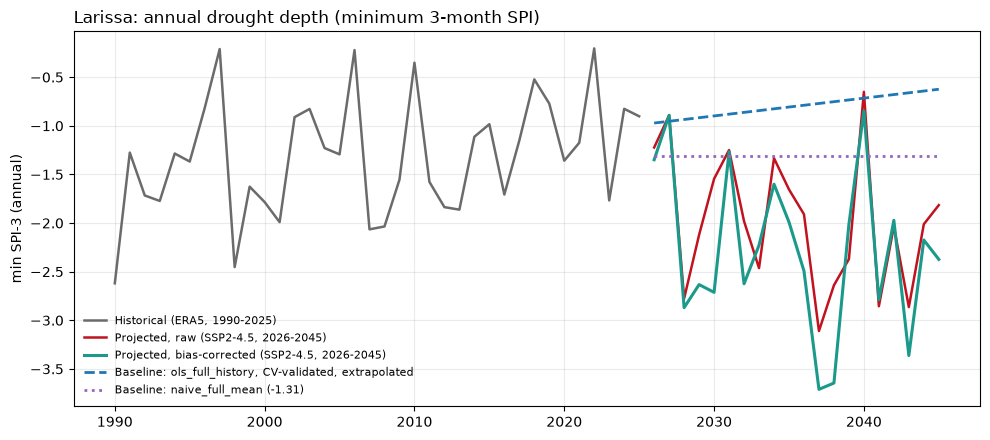

Historical mean: -1.31
Projected, bias-corrected: -2.28  (-0.97)
Projected, raw: -1.98  (-0.66)

SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme

Historical regression (1990-2025): +0.183/decade (p=0.06, not significant).  Corrected projection's own trend (2026-2045): -0.351/decade (p=0.28, not significant).  Ratio: -1.92x


In [10]:
spi3 = load("larissa_min_spi3_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(spi3)
b = fit_baselines(spi3, window=None)
plot_indicator(spi3, "min SPI-3 (annual)", "Larissa: annual drought depth (minimum 3-month SPI)", b, "ols_full_history, CV-validated")
print(f"Historical mean: {s['hist_mean']:.2f}")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f}  ({s['delta_corrected']:+.2f})")
print(f"Projected, raw: {s['raw_mean']:.2f}  ({s['delta_raw']:+.2f})")
print()
print("SPI drought categories: -1.0 to -1.49 = moderate | -1.5 to -1.99 = severe | <= -2.0 = extreme")
print()
print(trend_note(b))


**Result: a full drought-category jump, and a reversed trend direction -- the third precipitation
indicator to disagree with history, at nearly the same magnitude SSP5-8.5 showed.** Historical
`min_spi3` averages -1.31 (moderate drought) with a *marginally improving* trend (+0.18/decade,
p=0.06). The bias-corrected projection averages **-2.28 -- extreme drought territory** -- and its own
trend runs the opposite way, worsening at -0.35/decade (p=0.28). Raw (-1.98) agrees this is severe,
so it isn't a correction artifact. **Presentation note**: with `precip_total` and
`max_week_precip_mm`, this makes three independently-built indicators reversing Larissa's historical
precipitation story under SSP2-4.5 too -- and the level (-2.28) and direction of the reversal are
close enough to SSP5-8.5's own numbers (-2.45, -0.49/decade) that this now looks like a
scenario-independent property of how `cmcc_esm2` simulates Larissa, not an artifact of picking the
higher-emissions pathway. State this as a genuine, coherent tension worth further checking (a second
model), not as confirmed worsening drought risk.

## 5. Extreme Precipitation -- Annual Maximum 1-Day Rainfall (`rx1day_mm`)

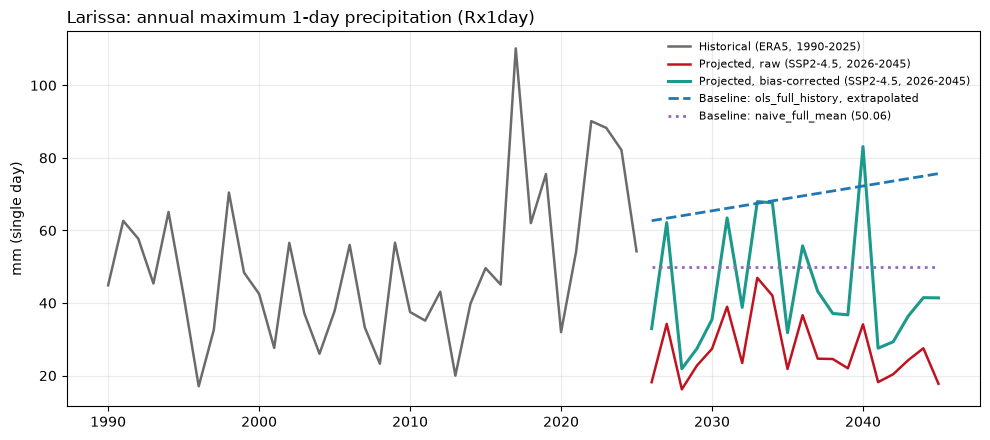

Historical mean: 50.1 mm
Projected, bias-corrected: 44.1 mm  (-6.0, -11.9%)
Projected, raw: 27.1 mm  (-23.0, -45.8%)

Historical regression (1990-2025): +6.828/decade (p=0.04, significant).  Corrected projection's own trend (2026-2045): -0.572/decade (p=0.93, not significant).  Ratio: -0.08x


In [11]:
rx1day = load("larissa_rx1day_mm_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(rx1day)
b = fit_baselines(rx1day, window=None)
plot_indicator(rx1day, "mm (single day)", "Larissa: annual maximum 1-day precipitation (Rx1day)", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.1f} mm")
print(f"Projected, bias-corrected: {s['corrected_mean']:.1f} mm  ({s['delta_corrected']:+.1f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.1f} mm  ({s['delta_raw']:+.1f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))

**Result: -11.9% (bias-corrected), historical to projection -- reversing the same significant
historical trend SSP5-8.5 reversed, at roughly half the magnitude.** Historical `rx1day_mm` averages
50.1mm with a genuinely significant increasing trend (+6.8mm/decade, p=0.04) -- the bias-corrected
SSP2-4.5 projection falls to 44.1mm, a smaller decline than SSP5-8.5's (-25.3%). The projection's own
trend is essentially flat (-0.57mm/decade, p=0.93) rather than SSP5-8.5's more clearly negative
slope. **Presentation note**: this is now the fourth precipitation indicator to reverse Larissa's
historical wetting story under SSP2-4.5 too, at a magnitude that scales down sensibly with the
lower-emissions pathway -- reinforcing that the reversal itself (not just its size) is a
scenario-independent property of how `cmcc_esm2` simulates Larissa.

## 6. Precipitation Intensity -- Simple Daily Intensity Index (`sdii_mm`)

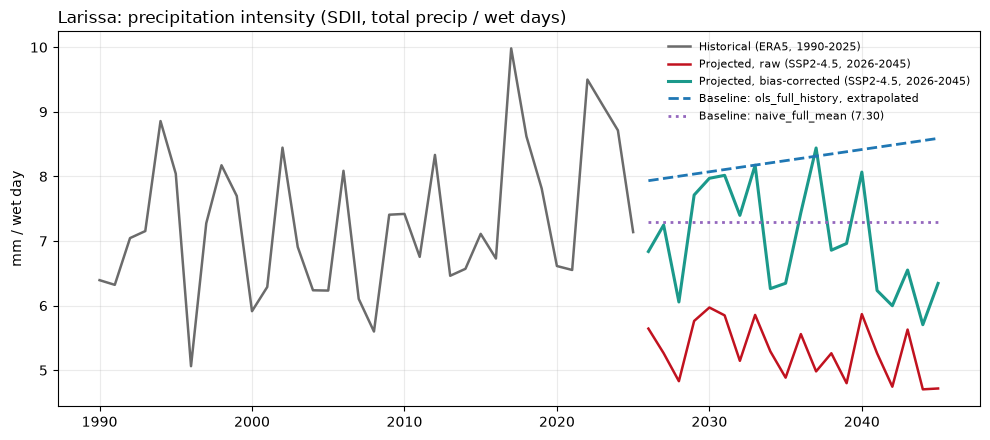

Historical mean: 7.30 mm/wet day
Projected, bias-corrected: 7.03 mm/wet day  (-0.27, -3.6%)
Projected, raw: 5.30 mm/wet day  (-1.99, -27.3%)

Historical regression (1990-2025): +0.345/decade (p=0.06, not significant).  Corrected projection's own trend (2026-2045): -0.535/decade (p=0.10, not significant).  Ratio: -1.55x


In [12]:
sdii = load("larissa_sdii_mm_era5_vs_cmip6_raw_vs_corrected", OUT_LARISSA)
s = change_stats(sdii)
b = fit_baselines(sdii, window=None)
plot_indicator(sdii, "mm / wet day", "Larissa: precipitation intensity (SDII, total precip / wet days)", b, "ols_full_history")
print(f"Historical mean: {s['hist_mean']:.2f} mm/wet day")
print(f"Projected, bias-corrected: {s['corrected_mean']:.2f} mm/wet day  ({s['delta_corrected']:+.2f}, {s['pct_corrected']:+.1f}%)")
print(f"Projected, raw: {s['raw_mean']:.2f} mm/wet day  ({s['delta_raw']:+.2f}, {s['pct_raw']:+.1f}%)")
print()
print(trend_note(b))

**Result: -3.6% (bias-corrected), historical to projection -- the smallest change of Larissa's
five precipitation-linked indicators, smaller still than SSP5-8.5's already-modest -5.4%.** SDII
falls from 7.30 to 7.03 mm/wet day. Neither the historical trend (+0.35/decade, p=0.06) nor the
projection's own (-0.53/decade, p=0.10) is significant. **Presentation note**: same reading as the
SSP5-8.5 notebook -- pair this with `rx1day_mm` above. The worst single day of the year gets notably
less extreme under either scenario, while typical rainy-day intensity is barely affected, suggesting
the historical wetting trend (and its projected reversal) is concentrated in extreme events rather
than everyday rainfall.

## Bottom line: chronic warming continues history; the precipitation story reverses it, under
either scenario

| Indicator | Historical | Projected (corrected) | Change | vs. SSP5-8.5's change |
|---|---|---|---|---|
| `tmin_mean` (chronic warming) | 11.52 degC | 12.63 degC | **+1.11 degC (+9.6%), on-trend** | +1.53 degC (+13.3%) |
| `precip_total` (precipitation) | 619.5 mm/yr | 513.7 mm/yr | **-106mm (-17.1%), reverses a significant historical trend** | -162mm (-26.2%) |
| `max_week_precip_mm` (flood peak) | 85.7 mm | 64.8-78.0 mm | **-9.0% to -24.4%, reverses history** | -30% to -37.5% |
| `min_spi3` (drought) | -1.31 (moderate) | -2.28 (extreme) | **-0.97, a full drought-category jump, trend reversed** | -1.14 (nearly identical) |
| `rx1day_mm` (worst single day) | 50.1 mm | 44.1 mm | **-11.9%, reverses a *significant* historical trend** | -25.3% |
| `sdii_mm` (typical rain-day intensity) | 7.30 mm/wet day | 7.03 mm/wet day | **-3.6%, modest, smaller than SSP5-8.5's** | -5.4% |

Larissa's chronic nighttime warming is the cleanest, most defensible number in this notebook, under
either scenario -- a confirmed historical trend, continuing smoothly into the projection at a
magnitude that scales sensibly with emissions (smaller under SSP2-4.5 than SSP5-8.5). The other five
indicators tell a different story: all five are built from precipitation, and all five run *against*
Larissa's historical record under **both** scenarios tried so far -- less annual rain, a less extreme
wettest week and worst single day, milder typical rain-day intensity, and deeper drought, where
history showed the opposite. That the reversal shows up under two different emissions pathways, at
broadly similar magnitude for `min_spi3` specifically and in the same direction (if smaller) for
every other indicator, is a stronger signal that this is a genuine property of `cmcc_esm2`'s
simulated Larissa climate than either scenario's result would be alone. `rx1day_mm` is worth
highlighting specifically: it reverses a historical trend that was itself independently significant
(p=0.04) under both scenarios -- the cleanest single piece of evidence for the reversal, since there
is no ambiguity about what the historical record actually showed.

**For the presentation**: don't present these six as a single unified narrative the way Seville's
five indicators can be. The honest framing is two separate stories -- **(1) chronic warming, confirmed
and continuing, scaling sensibly with emissions**, and **(2) a precipitation-side reversal that
contradicts 36 years of observed trends and shows up under both scenarios tested, worth flagging as an
open question rather than a resolved finding**, since it still rests on a single climate model's
simulation disagreeing with statistically significant historical data.

**Standard caveat, one last time**: one model, no ensemble spread -- and for the precipitation
reversal specifically, a second *model* (not just a second scenario, which this project has now
tried) would be the natural next check before this changes how Larissa's flood/drought risk gets
presented.

---

# Seville vs. Larissa: Two Climate Stories Under SSP2-4.5

Direct comparison of both cities' projections under the lower-emissions scenario, with the local
geography that explains why their historical climate signatures -- and their projected trajectories --
diverge the way they do. Geographic and historical-event details below are pulled from
`documentation/Seville_Larissa_Key_Findings_vs_Hypotheses.md`, not re-derived here -- identical to
the SSP5-8.5 notebook's own section, since geography doesn't depend on emissions scenario.

## Why these two cities aren't climatologically similar to begin with

| | Seville | Larissa |
|---|---|---|
| Location | 37.25-37.50N, 6.00-5.75W -- southern Spain, the Guadalquivir valley | 39.50-39.75N, 22.25-22.50E -- central Greece, the Thessalian plain |
| Setting | ~80 km from the Atlantic; mild, ocean-moderated winter | Inland plain ringed by mountains (Pindus to the west); no ocean moderation |
| January mean (ERA5, historical) | 10.6 degC | 5.1 degC -- genuinely continental |
| July mean (ERA5, historical) | 27.7 degC | 26.9 degC -- similar peak heat despite the winter gap |
| Annual temperature amplitude | 17.1 degC | 21.7 degC -- wider swings, continental climate |
| Distance apart | ~2,300 km -- no shared weather systems | |

Two real, documented events anchor each city's historical risk profile: **Seville's July 2022
heatwave** (peak 39.8 degC) and **April 2023 drought** (SPI-3 = -3.65, the most severe reading in the
36-year record). **Larissa's September 2023 Storm Daniel flood** (253mm in a single week) and its
**July 2023 heatwave**, notable because nighttime temperatures never dropped below the 20 degC
tropical-night threshold for 9 straight days -- which is why `tmin_mean` (not `tmax_mean`) is
Larissa's headline heat indicator.

## The projected stories, side by side (SSP2-4.5)

| | Seville (heat -> drought -> fire) | Larissa (chronic warming, precip split) |
|---|---|---|
| Temperature | `tmax_mean` +1.23 degC (+5.3%) -- continues history, significant trend | `tmin_mean` +1.11 degC (+9.6%) -- continues history, on-trend |
| Precipitation | `precip_total` -19mm (-3.9%) -- small, not statistically meaningful | `precip_total` -106mm (-17.1%) -- **reverses** a *significant* historical wetting trend |
| Extreme precip | (not separately tracked for Seville) | `max_week_precip_mm` -9.0% to -24.4% -- **reverses** history |
| Drought | `min_spi3` -0.82, moderate -> extreme category jump | `min_spi3` -0.97, moderate -> extreme category jump, trend also reverses |
| Fire risk | `days_fwi_gt30` +18.0 days (+14.7%) -- continues history | -- (no Larissa fire panel; flood risk is the closer analogue, and it points the opposite way from history) |

## The core comparative finding

**Seville's projection is directionally boring, in the best sense -- it continues the story its
historical record already tells, even under the lower-emissions pathway.** Hotter, marginally drier,
deeper drought, more fire-danger days: every indicator points the same way history already pointed,
just less dramatically than under SSP5-8.5 (except drought depth, which is nearly scenario-invariant).

**Larissa's projection splits its own historical story in two, under SSP2-4.5 exactly as it did under
SSP5-8.5.** The chronic-warming indicator (`tmin_mean`) behaves like Seville's temperature indicators
-- a clean continuation of an already-significant trend, scaled down sensibly for the lower-emissions
pathway. But every precipitation-linked indicator reverses direction, at a magnitude that varies by
indicator but agrees in direction with the SSP5-8.5 result: less annual rain, a less extreme wettest
week, deeper drought -- directly contradicting a *statistically significant* historical wetting trend.

**What having both scenarios now adds**: the SSP2-4.5 vs. SSP5-8.5 comparison itself is a separate,
statistically careful question -- see `Projected_Long_Term_2100/notebooks/SSP_Divergence_Study_Seville.ipynb`
and `..._Larissa.ipynb` for whether these two scenarios' projections are actually distinguishable from
single-run noise (short answer: temperature indicators separate from noise by around 2056-2065 in
both cities; precipitation-, drought-, and fire-linked indicators mostly don't separate at any point
through 2100). **The historical-vs-projection comparisons in this notebook and its SSP5-8.5 twin are
each individually defensible; treating the *difference between* the two notebooks' numbers as a
confirmed scenario effect is not**, for any indicator except the direct heat measures.

## A caveat specific to the precipitation divergence, worth having ready

**A lower projected *average* extreme-week precipitation does not mean events like Storm Daniel become
impossible, or even necessarily less likely.** `cmcc_esm2`'s native grid resolution is coarse --
roughly 0.94 degrees latitude by 1.25 degrees longitude, on the order of 100km, against ERA5's 0.25
degrees. Intense, localized convective/frontal rainfall events -- exactly the kind that produced Storm
Daniel -- are notoriously difficult for coarse-grid climate models to resolve; a model can show a
drier *average* future while still missing whether short, extreme events intensify. Read the
`max_week_precip_mm` reversal, under either scenario, as "this model's central tendency moved the
opposite way from history," not as "catastrophic flood risk is decreasing" -- those are different
claims, and only the first one is what this analysis actually supports.

## For the presentation

- **Lead with Seville** if the goal is a clean, confirmatory climate-risk story under either scenario
  -- every indicator agrees with itself, historically and going forward.
- **Use Larissa to show nuance and honesty**, not just a second confirmatory case -- a real signal
  (chronic warming) sitting alongside a real, unresolved tension (precipitation reversal), now
  confirmed under two independent emissions scenarios, is a more credible presentation than forcing
  both cities into the same "everything gets worse" narrative.
- **Use the SSP2-4.5-vs-SSP5-8.5 contrast carefully.** Where it exists (temperature), it's real and
  scales sensibly with emissions. Where it appears absent (drought depth landing at nearly the same
  level under both scenarios; precipitation reversal happening under both), that's not a data quality
  problem -- it's the documented signature of single-realization noise dominating the scenario signal
  at this near-term horizon for non-temperature indicators (see the divergence-study notebooks).
- **Both stories share the same limitation**: one model (`cmcc_esm2`), one realization per scenario,
  no ensemble spread. Seville's directional consistency makes that caveat feel less urgent; Larissa's
  reversal makes it essential to state explicitly.